<a href="https://colab.research.google.com/github/amandacfleal/detector-de-fraudes/blob/main/detector_fraude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seção 1: Carga, Diagnóstico Inicial e EDA Direta


Objetivo: Carregar os dados, inspecionar as dimensões e expor visualmente o desbalanceamento extremo de forma imediata.

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [58]:
contagens = df["Class"].value_counts().sort_index()
percentuais = (df["Class"].value_counts(normalize=True) * 100).sort_index()

resumo_classes = pd.DataFrame({
    'Quantidade': contagens,
    'Percentual (%)': percentuais.round(4)
})
resumo_classes.index = ['Normal (0)', 'Fraude (1)']

print("\nContagem e Percentual de Classes:")
display(resumo_classes)



Contagem e Percentual de Classes:


,Quantidade,Percentual (%)
Normal (0),284315,99.8273
Fraude (1),492,0.1727


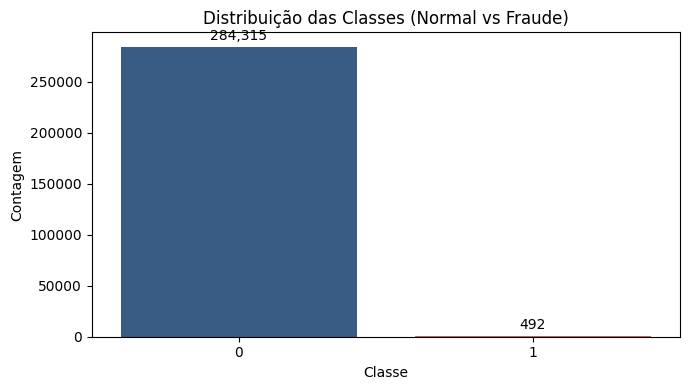

In [59]:

plt.figure(figsize=(7, 4))
ax = sns.countplot(x="Class", data=df, palette=['#2b5c8f', '#d9534f'], hue="Class", legend=False)
plt.title("Distribuição das Classes (Normal vs Fraude)")
plt.xlabel("Classe")
plt.ylabel("Contagem")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, color='black',
                xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

# Seção 2: Engenharia de Recursos (Feature Engineering) & Pré-processamento

Objetivo: Isolar as etapas de transformação do montante (Amount), padronização e divisão estratificada dos dados.




In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df["Amount_log"] = np.log1p(df["Amount"])
scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

print(f"Formato de treino: {X_train.shape}, Formato de teste: {X_test.shape}")

Formato de treino: (199364, 32), Formato de teste: (85443, 32)


# Seção 3: Abordagem de Reamostragem (Comparando Undersampling e SMOTE)

Objetivo: Criar e testar estratégias de reamostragem para avaliar qual método entrega melhores condições iniciais aos modelos.

In [61]:
# Abordagem A: Undersampling Manual com segurança
fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0]

n_fraudes = len(fraudes)
if n_fraudes > 0:
    normais_amostra = normais.sample(n=n_fraudes, random_state=42)
    df_under = pd.concat([fraudes, normais_amostra])

    X_under = df_under.drop("Class", axis=1)
    y_under = df_under["Class"]
else:
    print("Aviso: Nenhuma fraude encontrada para balancear.")

# Abordagem B: Oversampling com SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print("Instâncias após Undersampling:", X_under.shape)
print("Instâncias após SMOTE:", X_smote.shape)

Instâncias após Undersampling: (984, 32)
Instâncias após SMOTE: (568630, 32)


# Seção 4: Modelagem Comparativa (Baseline, Ensembles e Ajuste de Limiar)

Objetivo: Submeter os dados a diferentes classificadores (Regressão Logística, Random Forest e XGBoost), avaliando o impacto do peso de classes e alterando o limiar de decisão (threshold).

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# 1. Baseline - Regressão Logística
lr = LogisticRegression(max_iter=5000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("--- Regressão Logística (Baseline) ---")
print(classification_report(y_test, y_pred_lr))

# 2. Random Forest com class_weight
rf = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight="balanced", n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("--- Random Forest ---")
print(classification_report(y_test, y_pred_rf))

# 3. XGBoost com scale_pos_weight e Ajuste de Limiar (Threshold)
xgb = XGBClassifier(scale_pos_weight=10, eval_metric="logloss", random_state=42)
xgb.fit(X_train, y_train)

y_probs_xgb = xgb.predict_proba(X_test)[:, 1]
threshold = 0.3
y_pred_custom = (y_probs_xgb > threshold).astype(int)

print("--- XGBoost com Threshold Otimizado (0.3) ---")
print(classification_report(y_test, y_pred_custom))

--- Regressão Logística (Baseline) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.64      0.73       148

    accuracy                           1.00     85443
   macro avg       0.93      0.82      0.86     85443
weighted avg       1.00      1.00      1.00     85443

--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443

--- XGBoost com Threshold Otimizado (0.3) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.91      0.79      0.84       148

    accuracy                           1.00     85443
   macro avg       0.

# Seção 5: Curvas de Desempenho e Explicabilidade (SHAP)

Objetivo: Consolidar a avaliação por meio da curva Precision-Recall (a mais adequada para fraudes) e interpretar as decisões do modelo com o SHAP.

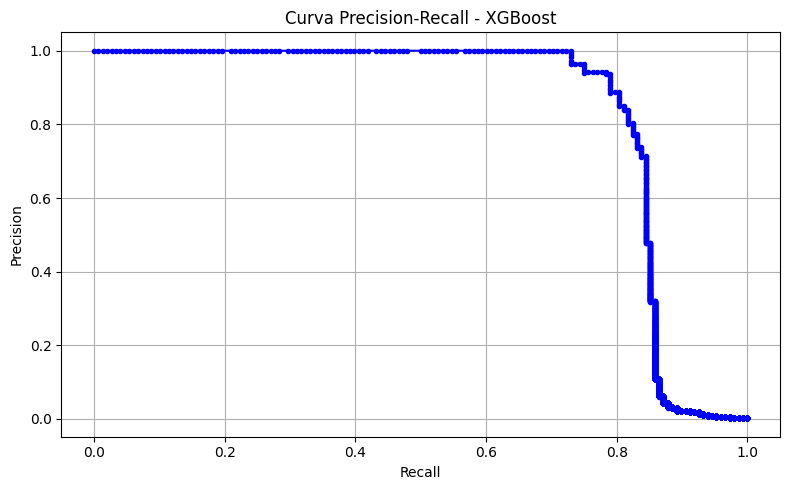

In [63]:
from sklearn.metrics import precision_recall_curve
import shap
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, y_probs_xgb)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, marker='.', color='b')
plt.title("Curva Precision-Recall - XGBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.tight_layout()
plt.show()


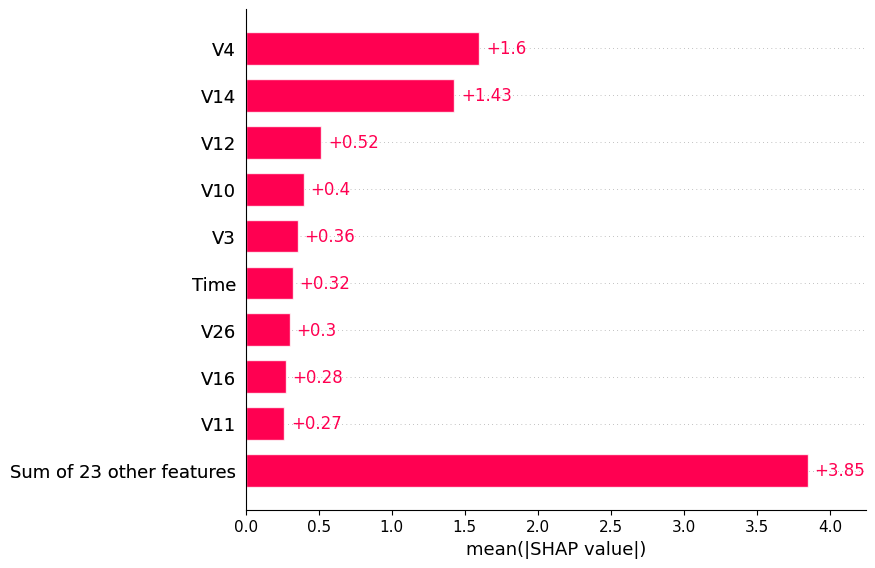

<Figure size 640x480 with 0 Axes>

In [64]:
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test[:100])

plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=10)
plt.tight_layout()
plt.show()